In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img, ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import Xception
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import zipfile




In [ ]:


orig_dir = '/content/'
zip_file = orig_dir + 'original_dataset_alz.zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(orig_dir)


In [ ]:


base_dir = orig_dir + '/augmented_data_set_final/OriginalDataset/'

In [ ]:
categories = ['MildDemented', 'ModerateDemented', 'VeryMildDemented','NonDemented']

In [ ]:
# Examine the dataset for imbalances - this is a very imbalanced data set! 6400 images in total
directory_path = []
for i in range(len(categories)):
    directory_paths = (base_dir +"/"+categories[i])
    image_count = len([file for file in os.listdir(directory_paths) if os.path.isfile(os.path.join(directory_paths, file))])
    print(f"Image count: {image_count} for {categories[i]}")

Image count: 896 for MildDemented
Image count: 64 for ModerateDemented
Image count: 2240 for VeryMildDemented
Image count: 3200 for NonDemented


In [2]:
# Counting the layers in Xception model. Total of 131 layers.
# Note that although Xception has 71 layers, this does not include the auxillary layers like batch normalization
# Use this to freeze the layers...
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)


83683744/83683744 [==============================] - 1s 0us/step
0 input_1 True
1 block1_conv1 True
2 block1_conv1_bn True
3 block1_conv1_act True
4 block1_conv2 True
5 block1_conv2_bn True
6 block1_conv2_act True
7 block2_sepconv1 True
8 block2_sepconv1_bn True
9 block2_sepconv2_act True
10 block2_sepconv2 True
11 block2_sepconv2_bn True
12 conv2d True
13 block2_pool True
14 batch_normalization True
15 add True
16 block3_sepconv1_act True
17 block3_sepconv1 True
18 block3_sepconv1_bn True
19 block3_sepconv2_act True
20 block3_sepconv2 True
21 block3_sepconv2_bn True
22 conv2d_1 True
23 block3_pool True
24 batch_normalization_1 True
25 add_1 True
26 block4_sepconv1_act True
27 block4_sepconv1 True
28 block4_sepconv1_bn True
29 block4_sepconv2_act True
30 block4_sepconv2 True
31 block4_sepconv2_bn True
32 conv2d_2 True
33 block4_pool True
34 batch_normalization_2 True
35 add_2 True
36 block5_sepconv1_act True
37 block5_sepconv1 True
38 block5_sepconv1_bn True
39 block5_sepconv2_act True

In [ ]:
# Rescaling and normalizing images

def load_images_and_labels(base_dir, target_size=(299, 299)):
    images, labels = [], []
    for category in os.listdir(base_dir):
        if category in ['MildDemented', 'ModerateDemented', 'VeryMildDemented']:
            class_label = 1
        elif category == 'NonDemented':
            class_label = 0
        else:
            continue
        category_dir = os.path.join(base_dir, category)
        for file_name in os.listdir(category_dir):
            file_path = os.path.join(category_dir, file_name)
            img = load_img(file_path, target_size=target_size)
            img = img_to_array(img)
            img /= 255.0
            images.append(img)
            labels.append(class_label)
    return np.array(images), np.array(labels)


images, labels = load_images_and_labels(base_dir)


train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
train_images, valid_images, train_labels, valid_labels = train_test_split(train_images, train_labels, test_size=0.25, random_state=42) # 0.25 x 0.8 = 0.2

In [ ]:
len(train_images ), len(valid_images), len(test_images)

(3840, 1280, 1280)

In [ ]:
# Data Augmentation
data_augmentation = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

In [ ]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3)) # Exclude the top fully connected layers
base_model.trainable = True
fine_tune_at = 132
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False #freezing the early layers up to 131

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),  # Reduce spatial dimensions of the output from base_model, makes it less prone to overfitting
    Dense(256, activation='relu'), # Relu to avoid overfitting
    BatchNormalization(), #Standardizes inputs to next layer. Should be placed after the Dense layer and before activation
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [ ]:
# Using the ADAM optimizer
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Epoch 1/100
120/120 [==============================] - 85s 636ms/step - loss: 0.7221 - accuracy: 0.6271 - val_loss: 0.6371 - val_accuracy: 0.6477 - lr: 0.0010
Epoch 2/100
120/120 [==============================] - 74s 616ms/step - loss: 0.6388 - accuracy: 0.6562 - val_loss: 0.5856 - val_accuracy: 0.6742 - lr: 0.0010
Epoch 3/100
120/120 [==============================] - 74s 618ms/step - loss: 0.6024 - accuracy: 0.6812 - val_loss: 0.5801 - val_accuracy: 0.7031 - lr: 0.0010
Epoch 4/100
120/120 [==============================] - 74s 618ms/step - loss: 0.5861 - accuracy: 0.6940 - val_loss: 0.5706 - val_accuracy: 0.7148 - lr: 0.0010
Epoch 5/100
120/120 [==============================] - 74s 620ms/step - loss: 0.5748 - accuracy: 0.6966 - val_loss: 0.6269 - val_accuracy: 0.6664 - lr: 0.0010
Epoch 6/100
120/120 [==============================] - 74s 619ms/step - loss: 0.5703 - accuracy: 0.7008 - val_loss: 0.5703 - val_accuracy: 0.7000 - lr: 0.0010
Epoch 7/100
120/120 [=========================

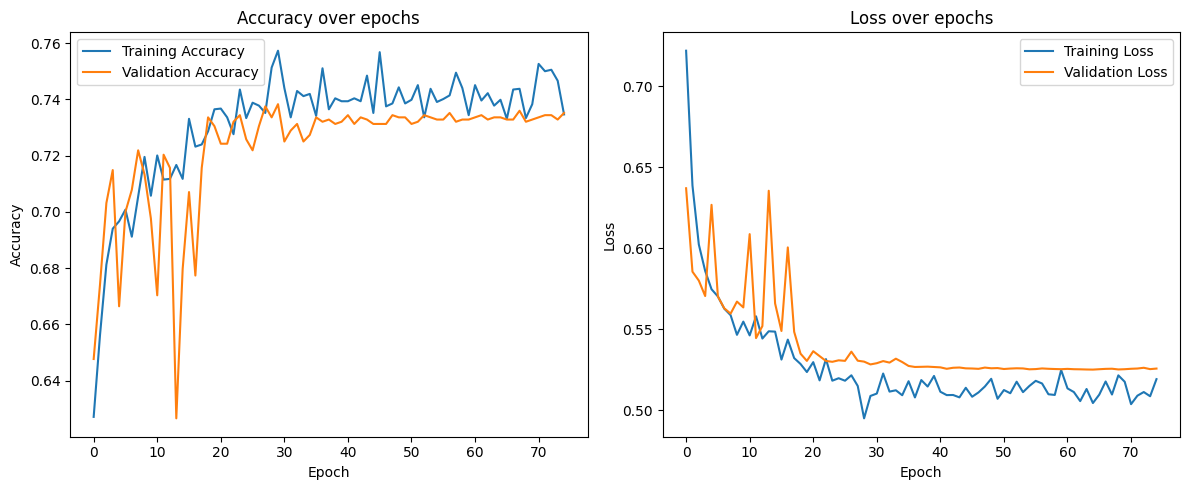

40/40 [==============================] - 5s 127ms/step - loss: 0.5362 - accuracy: 0.7281
Test accuracy: 72.81%
40/40 [==============================] - 6s 125ms/step


AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:



early_stopping = EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


history = model.fit(
    data_augmentation.flow(train_images, train_labels, batch_size=32),
    epochs=100,
    validation_data=(valid_images, valid_labels),
    callbacks=[early_stopping, reduce_lr])


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
#




40/40 [==============================] - 5s 124ms/step


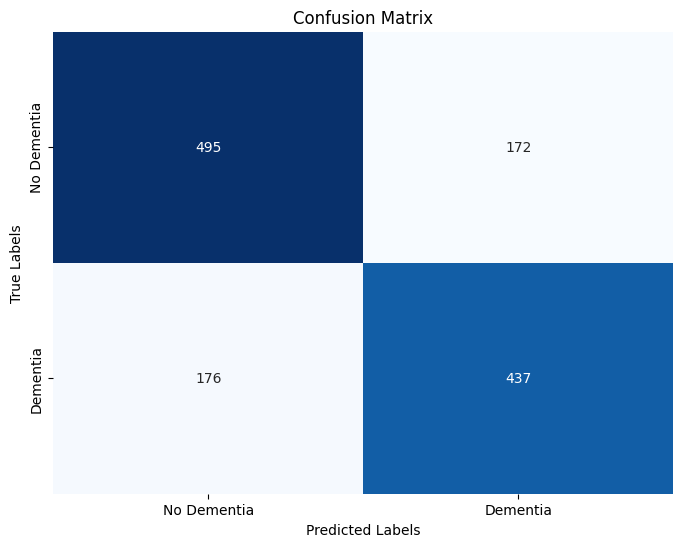

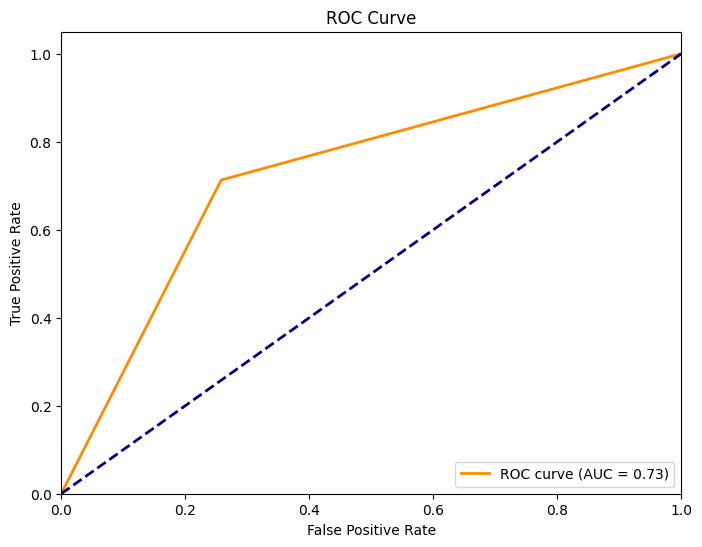

Classification Report:
              precision    recall  f1-score   support

 No Dementia       0.74      0.74      0.74       667
    Dementia       0.72      0.71      0.72       613

    accuracy                           0.73      1280
   macro avg       0.73      0.73      0.73      1280
weighted avg       0.73      0.73      0.73      1280



In [ ]:


test_predictions = model.predict(test_images)
test_predictions = (test_predictions > 0.5).astype(int)
conf_matrix = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Dementia', 'Dementia'],
            yticklabels=['No Dementia', 'Dementia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

fpr, tpr, thresholds = roc_curve(test_labels, test_predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print('Classification Report:')
print(classification_report(test_labels, test_predictions, target_names=['No Dementia', 'Dementia']))

In [ ]:
# FOR COMPARISON, I HAVE INCLUDED MY EARLIER RESULTS USING THE 4 CLASSIFICATIONS...

In [ ]:

#categories = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
num_classes = len(categories)
label_dict = {category: i for i, category in enumerate(categories)}

def load_images_and_labels(base_dir):
    images = []
    labels = []
    for category, label in label_dict.items():
        path = os.path.join(base_dir, category)
        for file in os.listdir(path):
            img_path = os.path.join(path, file)
            img = load_img(img_path, target_size=(299, 299))
            img = img_to_array(img)
            img /= 255.0
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)


images, labels = load_images_and_labels(base_dir)
labels = to_categorical(labels, num_classes=num_classes)


train_images, valid_images, train_labels, valid_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42)


data_augmentation = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')


base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = True
fine_tune_at = 132
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

history = model.fit(
    data_augmentation.flow(train_images, train_labels, batch_size=32),
    epochs=100,
    validation_data=(valid_images, valid_labels),
    callbacks=[early_stopping, reduce_lr])



Epoch 1/100
160/160 [==============================] - 102s 618ms/step - loss: 1.0226 - accuracy: 0.5096 - val_loss: 0.9587 - val_accuracy: 0.5109 - lr: 0.0010
Epoch 2/100
160/160 [==============================] - 97s 607ms/step - loss: 0.9556 - accuracy: 0.5391 - val_loss: 0.9175 - val_accuracy: 0.5289 - lr: 0.0010
Epoch 3/100
160/160 [==============================] - 97s 605ms/step - loss: 0.9344 - accuracy: 0.5479 - val_loss: 0.9200 - val_accuracy: 0.5312 - lr: 0.0010
Epoch 4/100
160/160 [==============================] - 97s 609ms/step - loss: 0.9193 - accuracy: 0.5525 - val_loss: 0.8960 - val_accuracy: 0.5344 - lr: 0.0010
Epoch 5/100
160/160 [==============================] - 98s 609ms/step - loss: 0.9165 - accuracy: 0.5566 - val_loss: 0.8929 - val_accuracy: 0.5523 - lr: 0.0010
Epoch 6/100
160/160 [==============================] - 97s 606ms/step - loss: 0.9031 - accuracy: 0.5713 - val_loss: 0.9074 - val_accuracy: 0.5422 - lr: 0.0010
Epoch 7/100
160/160 [========================

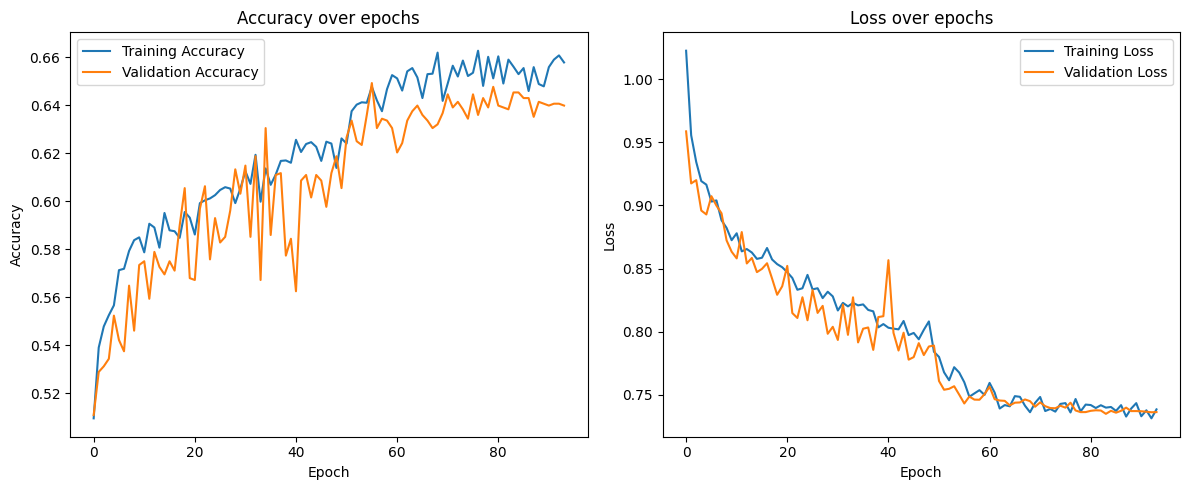

40/40 [==============================] - 6s 126ms/step


In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

valid_predictions = model.predict(valid_images)
valid_predicted_classes = np.argmax(valid_predictions, axis=1)
valid_true_classes = np.argmax(valid_labels, axis=1)



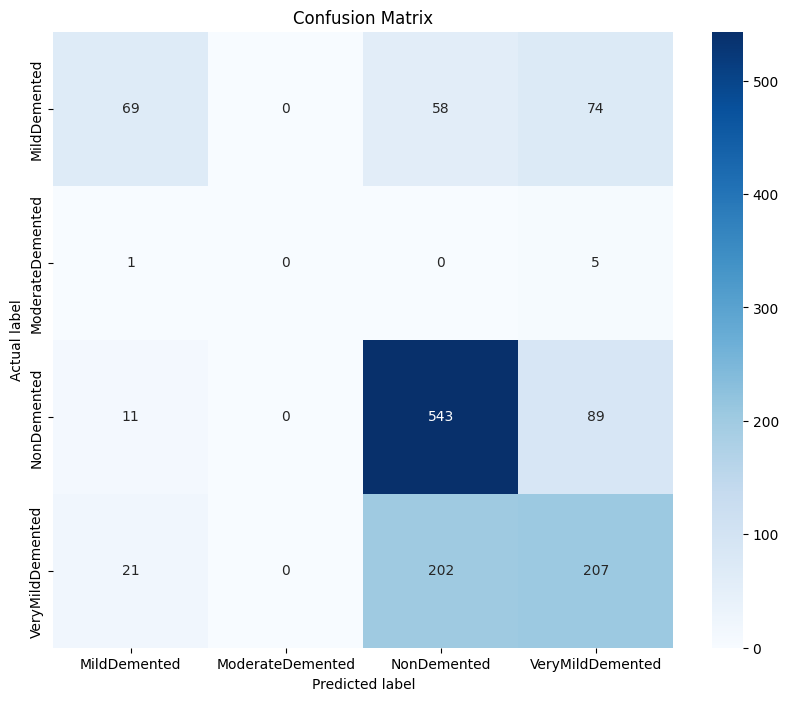

Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.68      0.34      0.46       201
ModerateDemented       0.00      0.00      0.00         6
     NonDemented       0.68      0.84      0.75       643
VeryMildDemented       0.55      0.48      0.51       430

        accuracy                           0.64      1280
       macro avg       0.48      0.42      0.43      1280
    weighted avg       0.63      0.64      0.62      1280



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
cm = confusion_matrix(valid_true_classes, valid_predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_dict.keys(), yticklabels=label_dict.keys())
plt.title('Confusion Matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

print('Classification Report:')
print(classification_report(valid_true_classes, valid_predicted_classes, target_names=label_dict.keys()))